In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

In [4]:

proliferative_aois=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Data/Nika_Masters_thesis_main_data/proliferative_aois.csv")
ssgsea_scores=pd.read_csv("/Volumes/h30492/farkkilab2/9_EyeMT/Data_analysis/geomx_processing/batch123-2808/pathway_analysis/gsea/ssgsea_norm_harmony_batch_corr_q3_norm_all_msigdb.csv")

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_2344/1182489400.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  ssgsea_scores=pd.read_csv("/Volumes/h30492/farkkilab2/9_EyeMT/Data_analysis/geomx_processing/batch123-2808/pathway_analysis/gsea/ssgsea_norm_harmony_batch_corr_q3_norm_all_msigdb.csv")


## Checking clustering based on the most variable pathways

In [5]:

wide_ssgsea =ssgsea_scores.pivot(
    index=["dcc_filename", "Sample"],
    columns="pathway",
    values="ssgsea_score"
)

wide_ssgsea.index = wide_ssgsea.index.rename(["dcc_filename_1", "Sample"])
wide_ssgsea =wide_ssgsea.reset_index()
wide_ssgsea["dcc_filename_1"] = wide_ssgsea["dcc_filename_1"].astype(str)
#wide_hallmark_ssgsea["Sample"] = wide_hallmark_ssgsea["Sample"].astype(str)
merged_df_ssgsea = pd.merge(
    wide_ssgsea,
    proliferative_aois,
    on="dcc_filename_1",
    how="inner"
)


Random Forest selected 3100 pathways.


/opt/anaconda3/envs/scimap/lib/python3.10/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/scimap/lib/python3.10/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


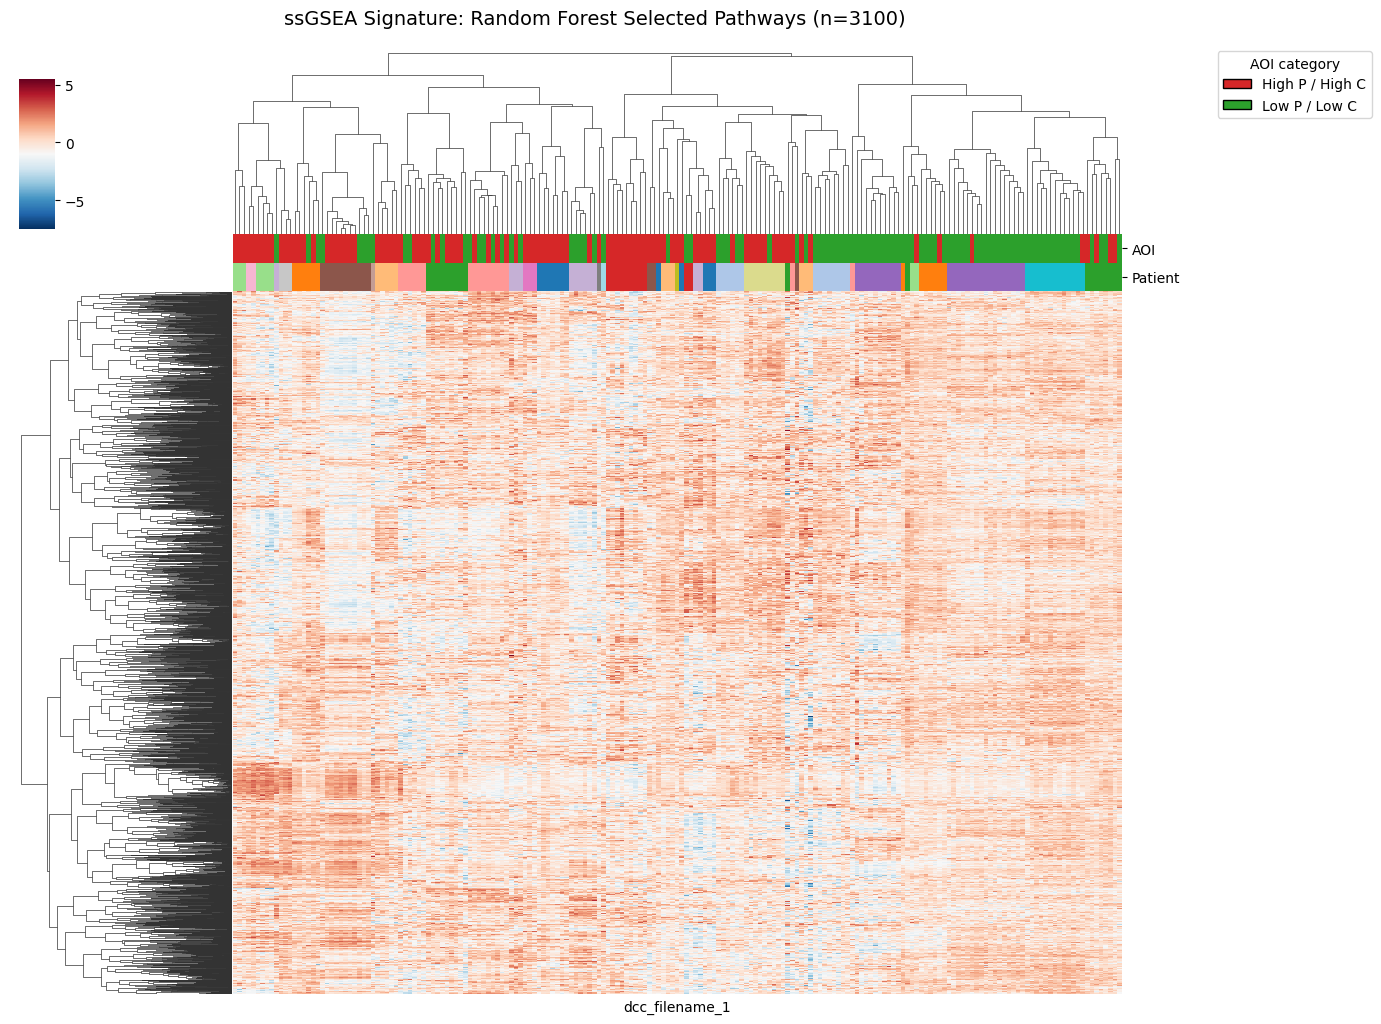

In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1. Identify Pathway Columns & Metadata
# -----------------------------
all_ssgsea_pathways = wide_ssgsea.columns.difference(["dcc_filename_1", "Sample"]).tolist()

# -----------------------------
# 2. Filter for specific categories FIRST
# -----------------------------
target_categories = ["High P / High C", "Low P / Low C"]
df_filtered = merged_df_ssgsea[merged_df_ssgsea["AOI_category"].isin(target_categories)].copy()

# Ensure pathway data is numeric
df_filtered[all_ssgsea_pathways] = df_filtered[all_ssgsea_pathways].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

# -----------------------------
# 3. Random Forest Feature Selection
# -----------------------------
X = df_filtered[all_ssgsea_pathways]
y = df_filtered["AOI_category"]

# Fit Random Forest to find predictive features
rf = RandomForestClassifier(n_estimators=2000, random_state=42, class_weight='balanced')
rf.fit(X, y)

# Extract importance scores
importances = pd.Series(rf.feature_importances_, index=all_ssgsea_pathways)

# Filter: Keep pathways with importance above the mean
threshold = importances.median() 

top_n = 500
top_pathways_rf = importances.head(top_n).index
top_pathways_rf = importances[importances >= threshold].sort_values(ascending=False).index
print(f"Random Forest selected {len(top_pathways_rf)} pathways.")
#print(f"Random Forest selected {len(top_pathways_rf)} pathways.")

# -----------------------------
# 4. Prepare Matrix
# -----------------------------
data = df_filtered.set_index("dcc_filename_1")[top_pathways_rf].T

# -----------------------------
# 5. Annotation Colors
# -----------------------------
palette = {
    "High P / High C": "#d62728",
    "Low P / Low C": "#2ca02c"
}

sample_col = "Sample_x" if "Sample_x" in df_filtered.columns else "Sample"
unique_samples = df_filtered[sample_col].unique()
sample_pal = dict(zip(unique_samples, sns.color_palette("tab20", len(unique_samples))))

col_colors = pd.DataFrame({
    "AOI": df_filtered.set_index("dcc_filename_1")["AOI_category"].map(palette),
    "Patient": df_filtered.set_index("dcc_filename_1")[sample_col].map(sample_pal)
})

# -----------------------------
# 6. CLUSTERMAP (Labels Removed)
# -----------------------------
g = sns.clustermap(
    data,
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    z_score=0,             
    cmap="RdBu_r",
    figsize=(12, 10),      
    xticklabels=False,     # No AOI names
    yticklabels=False, 
    #method="ward",
    #metric="euclidean",
    method="complete",
    metric="correlation",
    cbar_pos=(0.02, 0.8, 0.03, 0.15) 
)

# -----------------------------
# 7. Legend
# -----------------------------
handles = [
    Patch(facecolor=palette[label], edgecolor="black", label=label)
    for label in target_categories
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="AOI category",
    loc="upper left",
    bbox_to_anchor=(1.1, 1),
    frameon=True
)

g.fig.suptitle(f"ssGSEA Signature: Random Forest Selected Pathways (n={len(top_pathways_rf)})", y=1.02, fontsize=14)

plt.show()

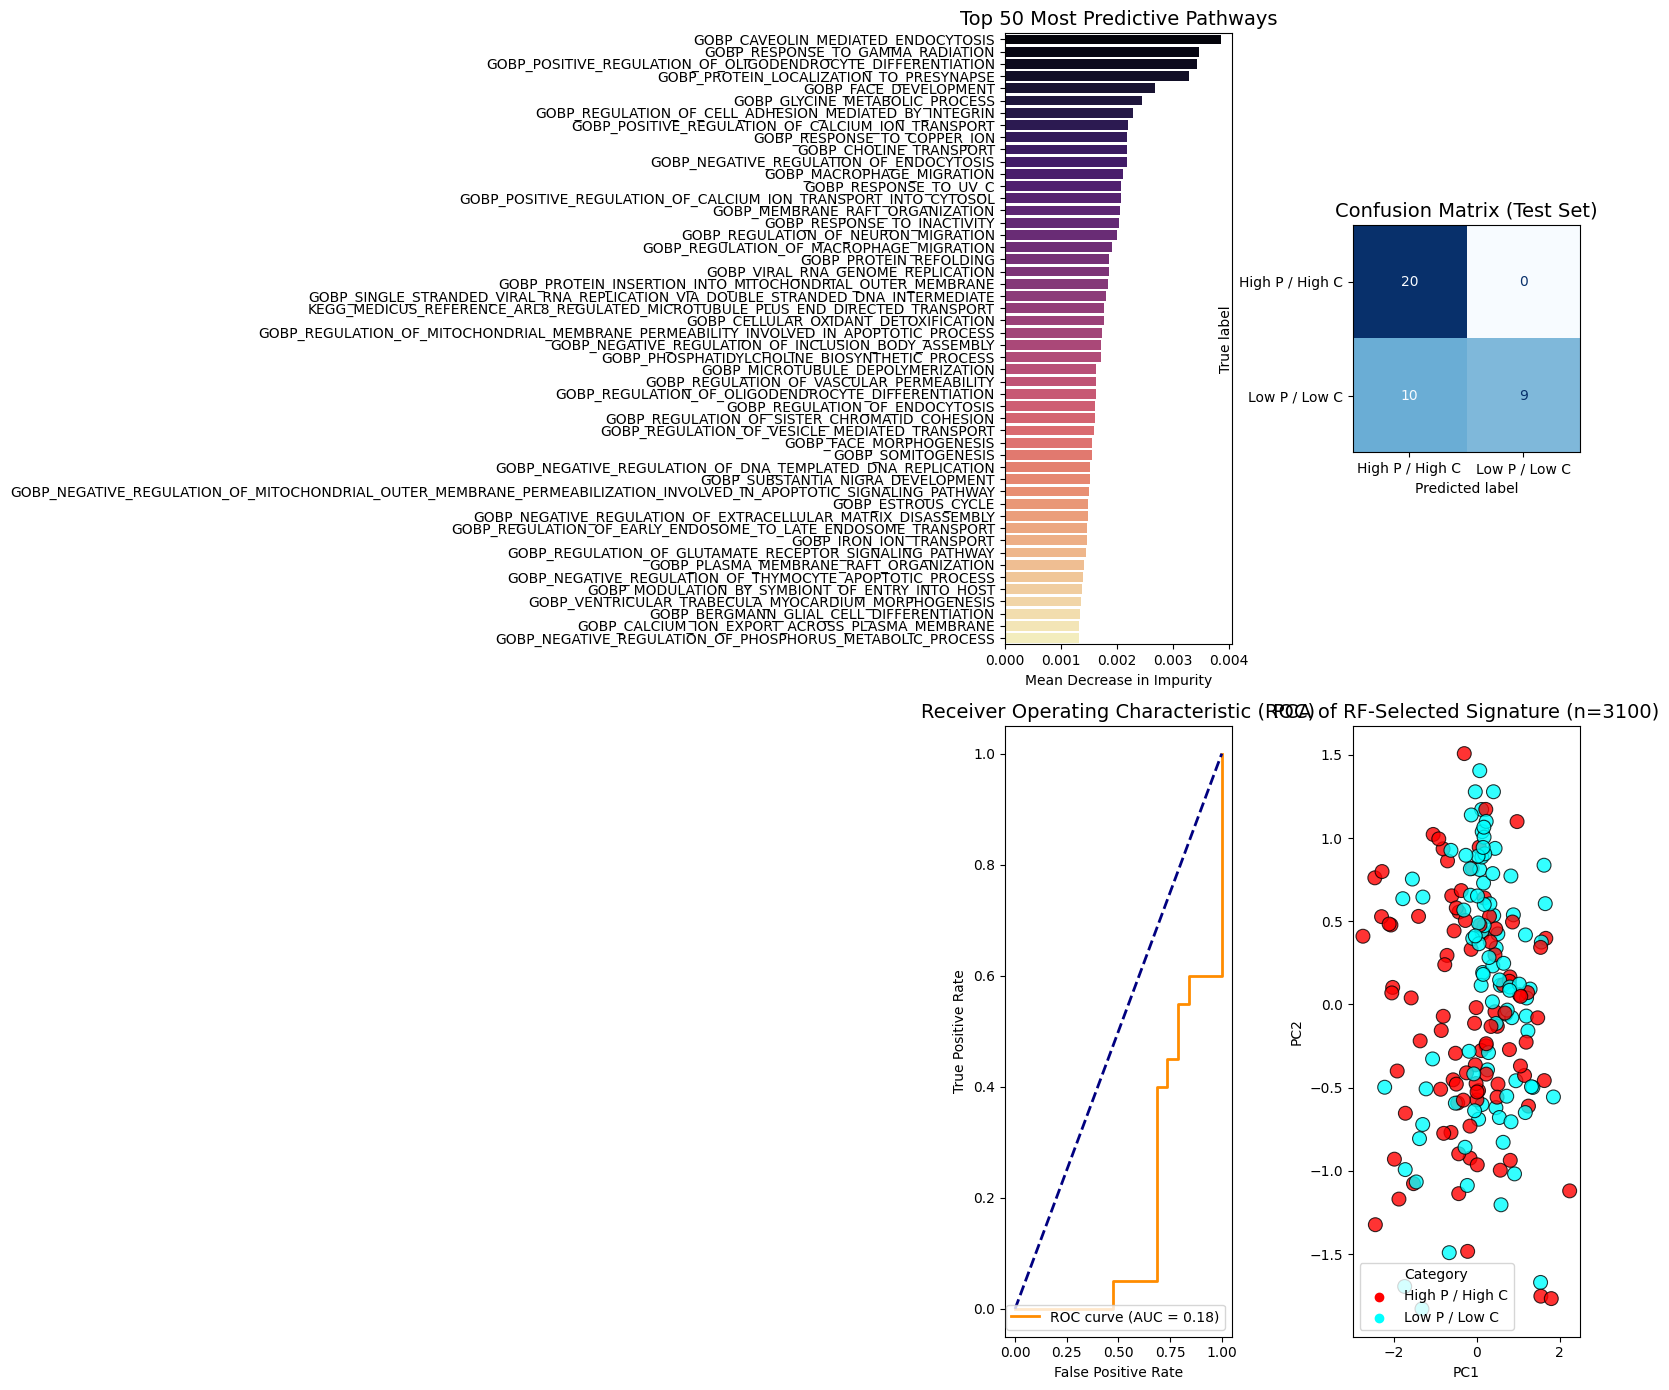

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Prepare Data
# -----------------------------
all_ssgsea_pathways = wide_ssgsea.columns.difference(["dcc_filename_1", "Sample"]).tolist()
target_categories = ["High P / High C", "Low P / Low C"]
df_filtered = merged_df_ssgsea[merged_df_ssgsea["AOI_category"].isin(target_categories)].copy()

X = df_filtered[all_ssgsea_pathways].apply(pd.to_numeric, errors="coerce").fillna(0)
y = df_filtered["AOI_category"]

# Split data for validation (80% train, 20% test) to make ROC/Confusion Matrix meaningful
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# -----------------------------
# 2. Train Random Forest
# -----------------------------
rf = RandomForestClassifier(n_estimators=2000, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Calculate Importance for ALL data for plotting
importances = pd.Series(rf.feature_importances_, index=all_ssgsea_pathways).sort_values(ascending=False)

# -----------------------------
# 3. VISUALIZATIONS
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- A. Top 20 Feature Importance ---
sns.barplot(x=importances.head(50).values, y=importances.head(50).index, ax=axes[0, 0], palette="magma")
axes[0, 0].set_title("Top 50 Most Predictive Pathways", fontsize=14)
axes[0, 0].set_xlabel("Mean Decrease in Impurity")

# --- B. Confusion Matrix ---
y_pred = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0, 1], cmap="Blues", colorbar=False)
axes[0, 1].set_title("Confusion Matrix (Test Set)", fontsize=14)

# --- C. ROC Curve ---
y_prob = rf.predict_proba(X_test)[:, 1]
# Convert labels to binary for ROC: High P / High C = 1
y_test_bin = (y_test == "High P / High C").astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
roc_auc = auc(fpr, tpr)

axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_title("Receiver Operating Characteristic (ROC)", fontsize=14)
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend(loc="lower right")

# --- D. PCA of Selected Features ---
# Use pathways that are above the median importance
selected_feats = importances[importances >= importances.median()].index
X_selected = X[selected_feats]
pca = PCA(n_components=2)
components = pca.fit_transform(X_selected)

pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['Category'] = y.values

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Category', 
                palette={"High P / High C": "#FF0000", "Low P / Low C": "#00FFFF"}, 
                ax=axes[1, 1], s=100, alpha=0.8, edgecolor="black")
axes[1, 1].set_title(f"PCA of RF-Selected Signature (n={len(selected_feats)})", fontsize=14)

plt.tight_layout()
plt.show()

## Random forest performance with the umap 

/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_11098/783421963.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(50).values, y=importances.head(50).index, ax=ax_imp, palette="magma")


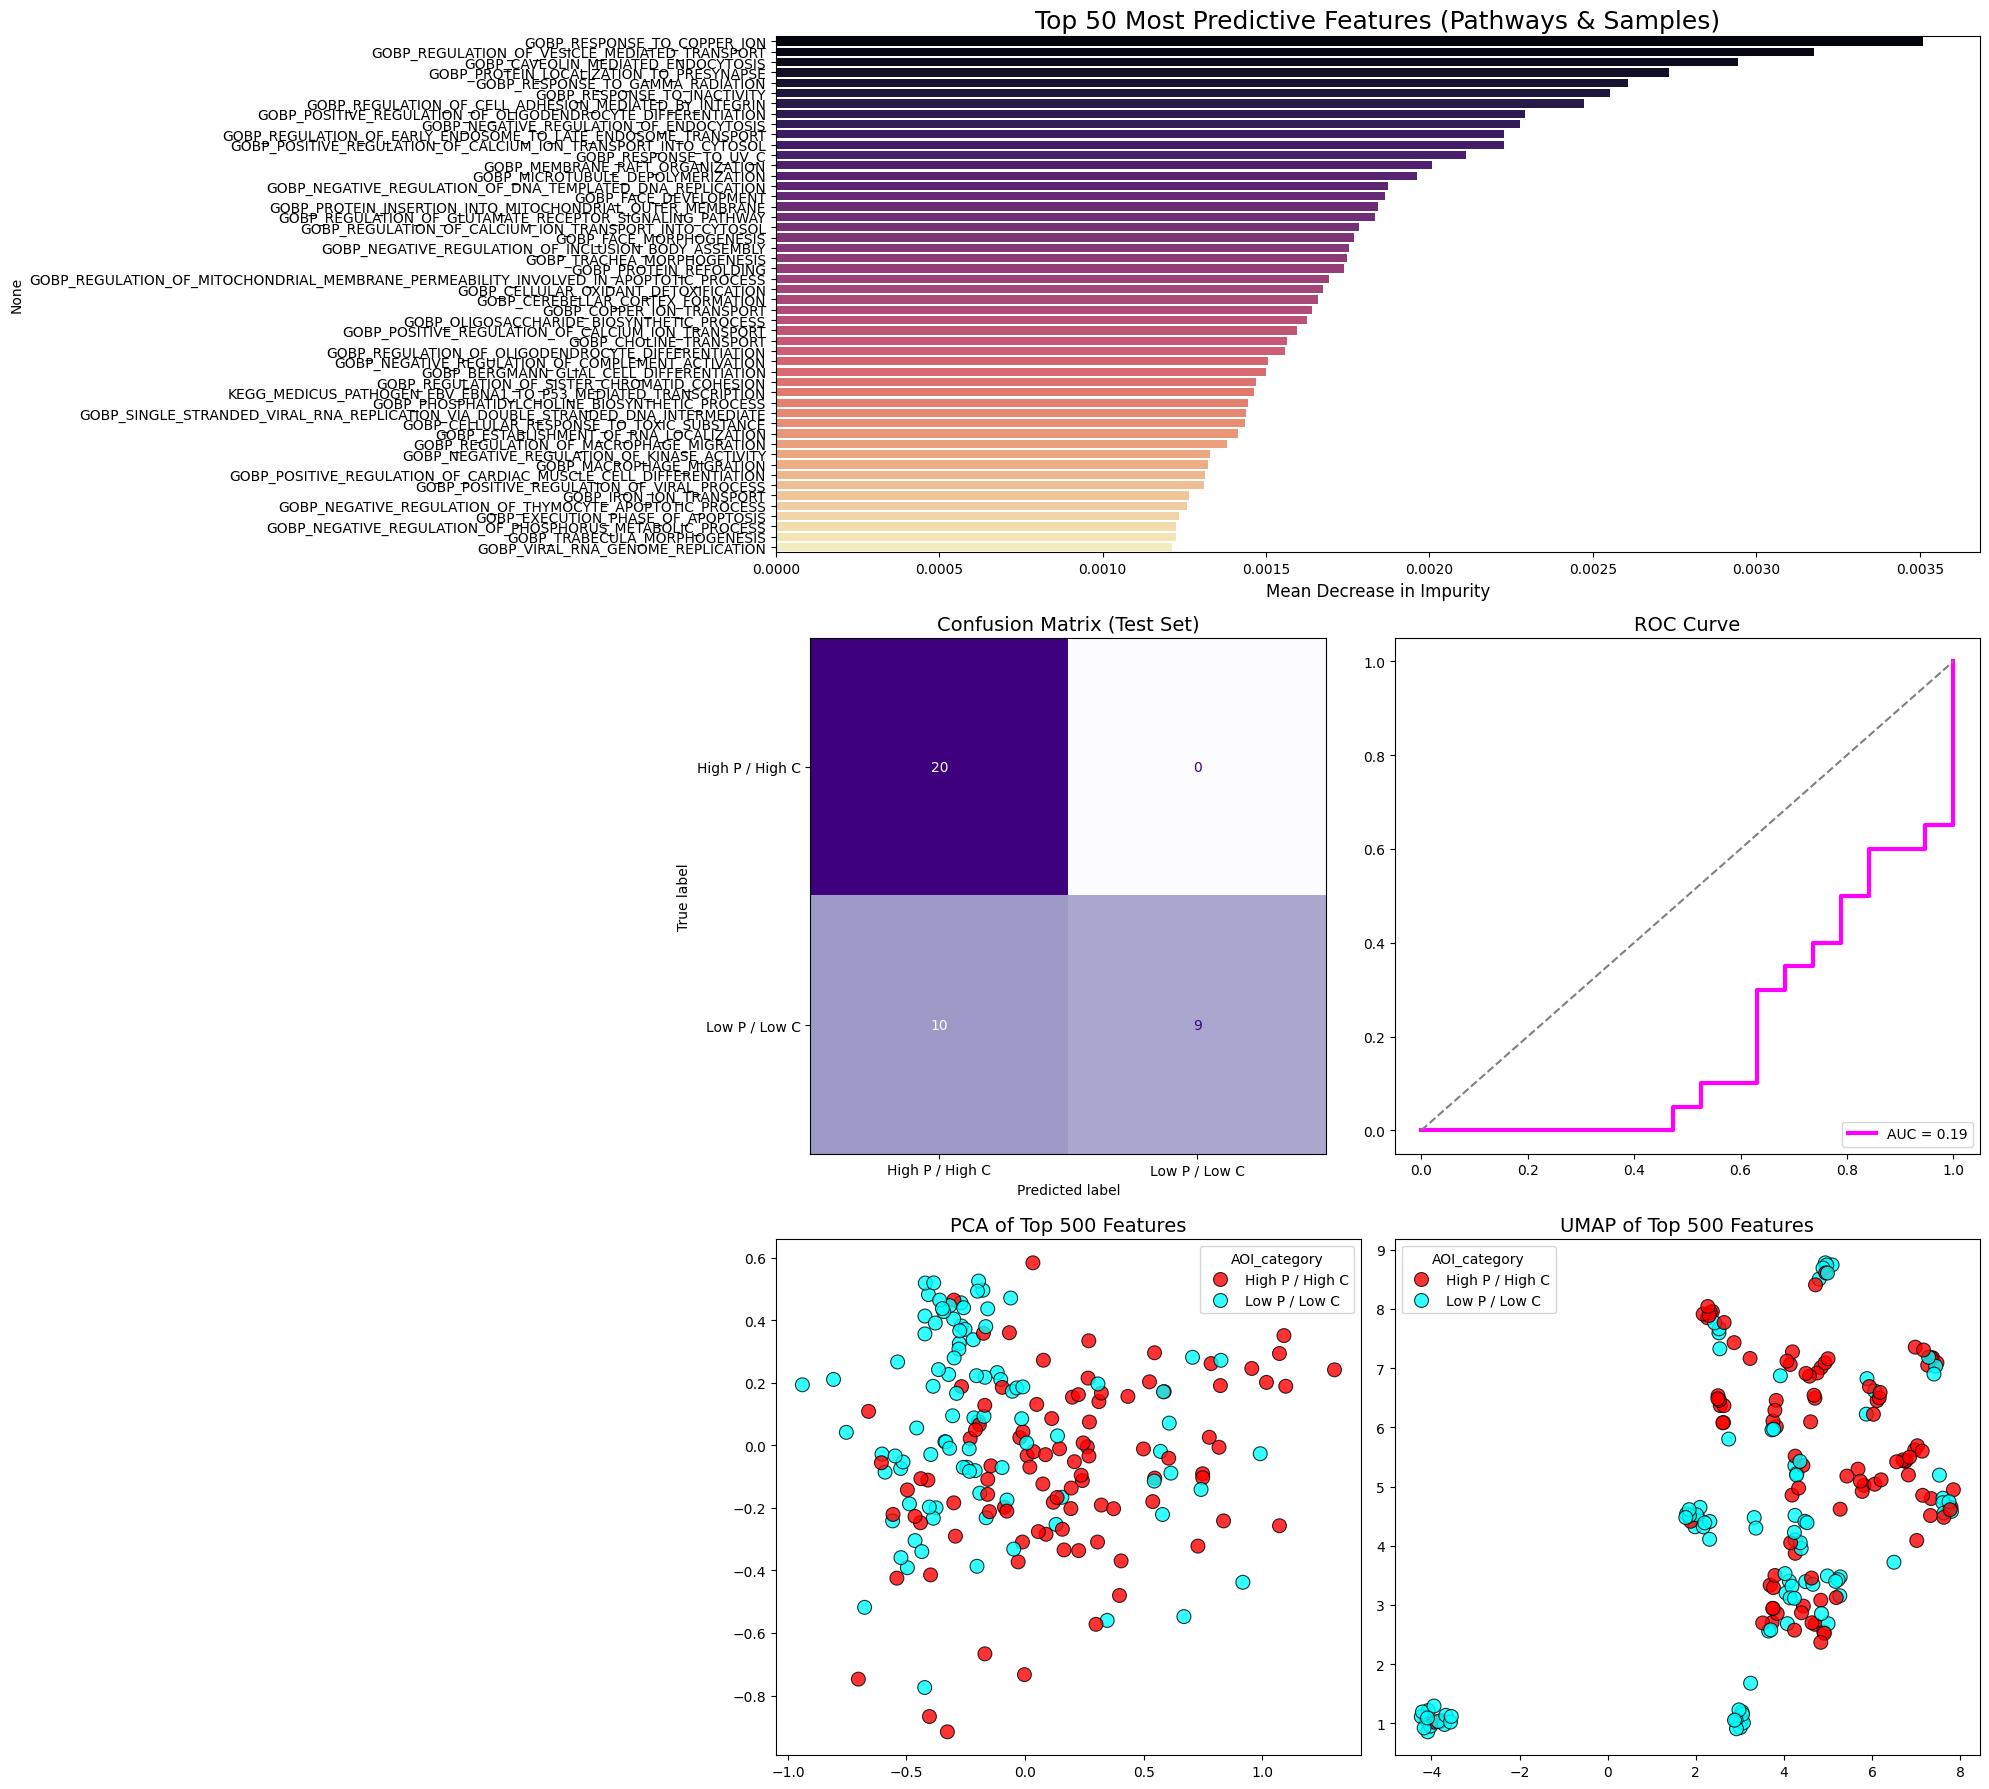

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Prepare Data
# -----------------------------
# Including Sample Covariates as features (without "Patient" prefix)
sample_dummies = pd.get_dummies(df_filtered['Sample'], prefix='', prefix_sep='')
all_pathways = wide_ssgsea.columns.difference(["dcc_filename_1", "Sample"]).tolist()

# Combine Pathways and Sample Covariates
X_full = pd.concat([df_filtered[all_pathways], sample_dummies], axis=1)
X_full = X_full.apply(pd.to_numeric, errors="coerce").fillna(0)
y = df_filtered["AOI_category"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42, stratify=y)

# -----------------------------
# 2. Train Random Forest
# -----------------------------
rf = RandomForestClassifier(n_estimators=2000, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values(ascending=False)
selected_feats = importances.head(500).index
X_selected = X_full[selected_feats]

# -----------------------------
# 3. Dimensionality Reduction (PCA & UMAP)
# -----------------------------
# PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_selected)

# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer.fit_transform(X_selected)

# -----------------------------
# 4. VISUALIZATIONS (Grid Layout)
# -----------------------------
fig = plt.figure(figsize=(20, 18))
# Create a 3-row, 2-column grid
# Row 0: Importance (Spans both columns)
# Row 1: Confusion Matrix & ROC
# Row 2: PCA & UMAP
ax_imp = plt.subplot2grid((3, 2), (0, 0), colspan=2)
ax_cm = plt.subplot2grid((3, 2), (1, 0))
ax_roc = plt.subplot2grid((3, 2), (1, 1))
ax_pca = plt.subplot2grid((3, 2), (2, 0))
ax_umap = plt.subplot2grid((3, 2), (2, 1))

plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- A. TOP ROW: Top 50 Feature Importance ---
sns.barplot(x=importances.head(50).values, y=importances.head(50).index, ax=ax_imp, palette="magma")
ax_imp.set_title("Top 50 Most Predictive Features (Pathways & Samples)", fontsize=18)
ax_imp.set_xlabel("Mean Decrease in Impurity", fontsize=12)

# --- B. Confusion Matrix ---
y_pred = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax_cm, cmap="Purples", colorbar=False)
ax_cm.set_title("Confusion Matrix (Test Set)", fontsize=14)

# --- C. ROC Curve ---
y_prob = rf.predict_proba(X_test)[:, 1]
y_test_bin = (y_test == "High P / High C").astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
roc_auc = auc(fpr, tpr)
ax_roc.plot(fpr, tpr, color='#FF00FF', lw=3, label=f'AUC = {roc_auc:.2f}')
ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax_roc.set_title("ROC Curve", fontsize=14)
ax_roc.legend(loc="lower right")

# --- D. PCA ---
palette = {"High P / High C": "#FF0000", "Low P / Low C": "#00FFFF"}
sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], hue=y, ax=ax_pca, palette=palette, s=100, edgecolor="black", alpha=0.8)
ax_pca.set_title("PCA of Top 500 Features", fontsize=14)

# --- E. UMAP ---
sns.scatterplot(x=umap_results[:,0], y=umap_results[:,1], hue=y, ax=ax_umap, palette=palette, s=100, edgecolor="black", alpha=0.8)
ax_umap.set_title("UMAP of Top 500 Features", fontsize=14)

plt.tight_layout()
plt.show()

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_9172/4219448655.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(20).values, y=importances.head(20).index, ax=axes[0, 0], palette="magma")


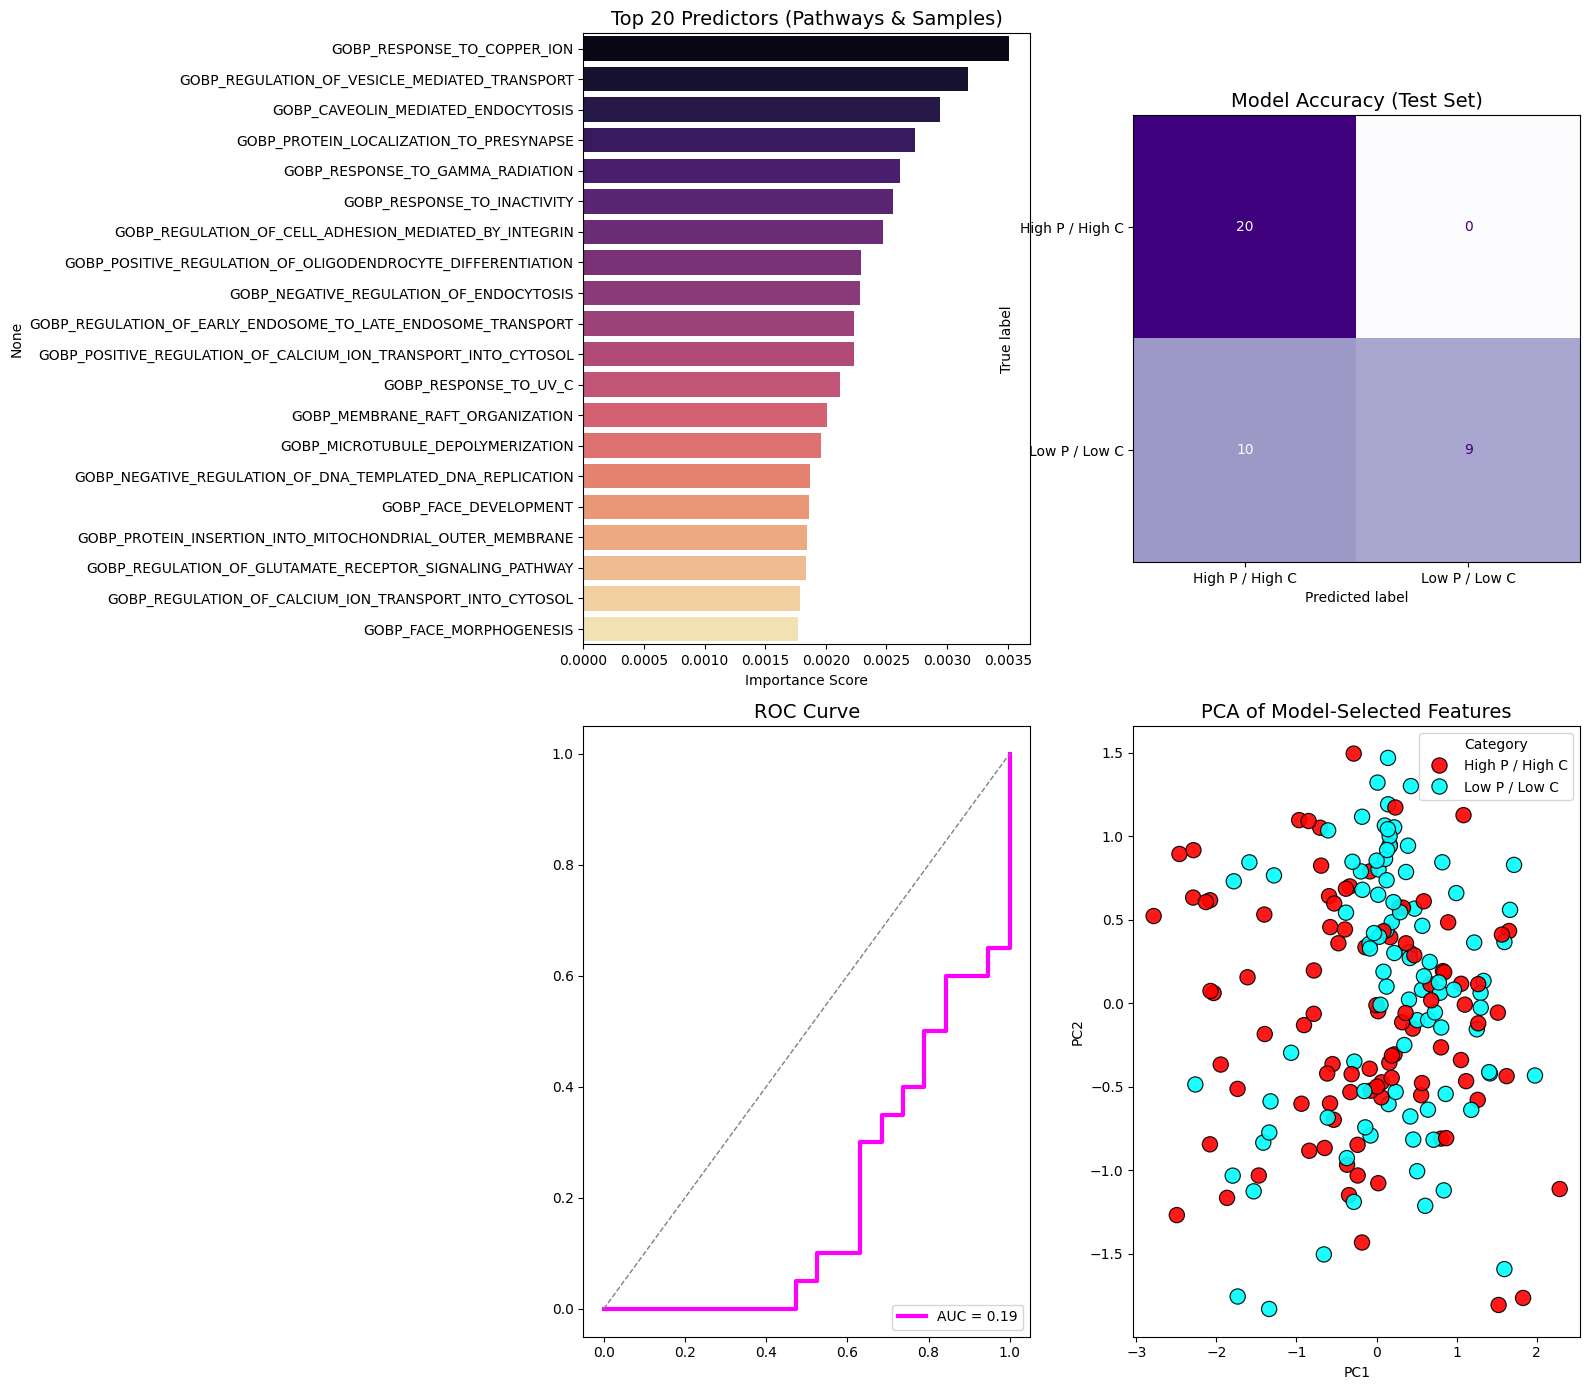

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. Identify ALL Pathways & Metadata
# ---------------------------------------------------------
# Get every pathway available in your ssGSEA results
all_pathways = wide_ssgsea.columns.difference(["dcc_filename_1", "Sample"]).tolist()

target_categories = ["High P / High C", "Low P / Low C"]
df_filtered = merged_df_ssgsea[merged_df_ssgsea["AOI_category"].isin(target_categories)].copy()

# ---------------------------------------------------------
# 2. Encode Sample Covariates (No Prefix)
# ---------------------------------------------------------
# One-hot encode samples. Prefix is set to "" so columns are just the Sample names.
sample_dummies = pd.get_dummies(df_filtered['Sample'], prefix='', prefix_sep='')

# Combine Pathways with Sample Covariates
X = pd.concat([df_filtered[all_pathways], sample_dummies], axis=1)
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
y = df_filtered["AOI_category"]

# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------------------------------------
# 3. Train Random Forest
# ---------------------------------------------------------
rf = RandomForestClassifier(n_estimators=2000, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Calculate Importance for ALL features (Pathways + Samples)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# ---------------------------------------------------------
# 4. HIGH-CONTRAST DIAGNOSTICS
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- A. Top 20 Features (Pathways vs. Samples) ---
# This plot will show if a specific Sample is more predictive than the pathways
sns.barplot(x=importances.head(20).values, y=importances.head(20).index, ax=axes[0, 0], palette="magma")
axes[0, 0].set_title("Top 20 Predictors (Pathways & Samples)", fontsize=14)
axes[0, 0].set_xlabel("Importance Score")

# --- B. Confusion Matrix ---
y_pred = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0, 1], cmap="Purples", colorbar=False)
axes[0, 1].set_title("Model Accuracy (Test Set)", fontsize=14)

# --- C. ROC Curve ---
y_prob = rf.predict_proba(X_test)[:, 1]
y_test_bin = (y_test == "High P / High C").astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
roc_auc = auc(fpr, tpr)

axes[1, 0].plot(fpr, tpr, color='#FF00FF', lw=3, label=f'AUC = {roc_auc:.2f}')
axes[1, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1, 0].set_title("ROC Curve", fontsize=14)
axes[1, 0].legend(loc="lower right")

# --- D. PCA of RF-Selected Signature ---
# Use top features (pathways + samples) above median importance
selected_feats = importances[importances >= importances.median()].index
X_selected = X[selected_feats]
pca = PCA(n_components=2)
components = pca.fit_transform(X_selected)

pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['Category'] = y.values

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Category', 
                palette={"High P / High C": "#FF0000", "Low P / Low C": "#00FFFF"}, 
                ax=axes[1, 1], s=120, alpha=0.9, edgecolor="black")
axes[1, 1].set_title("PCA of Model-Selected Features", fontsize=14)

plt.tight_layout()
plt.show()

RF selected 1949 features (Pathways + Sample IDs).


/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


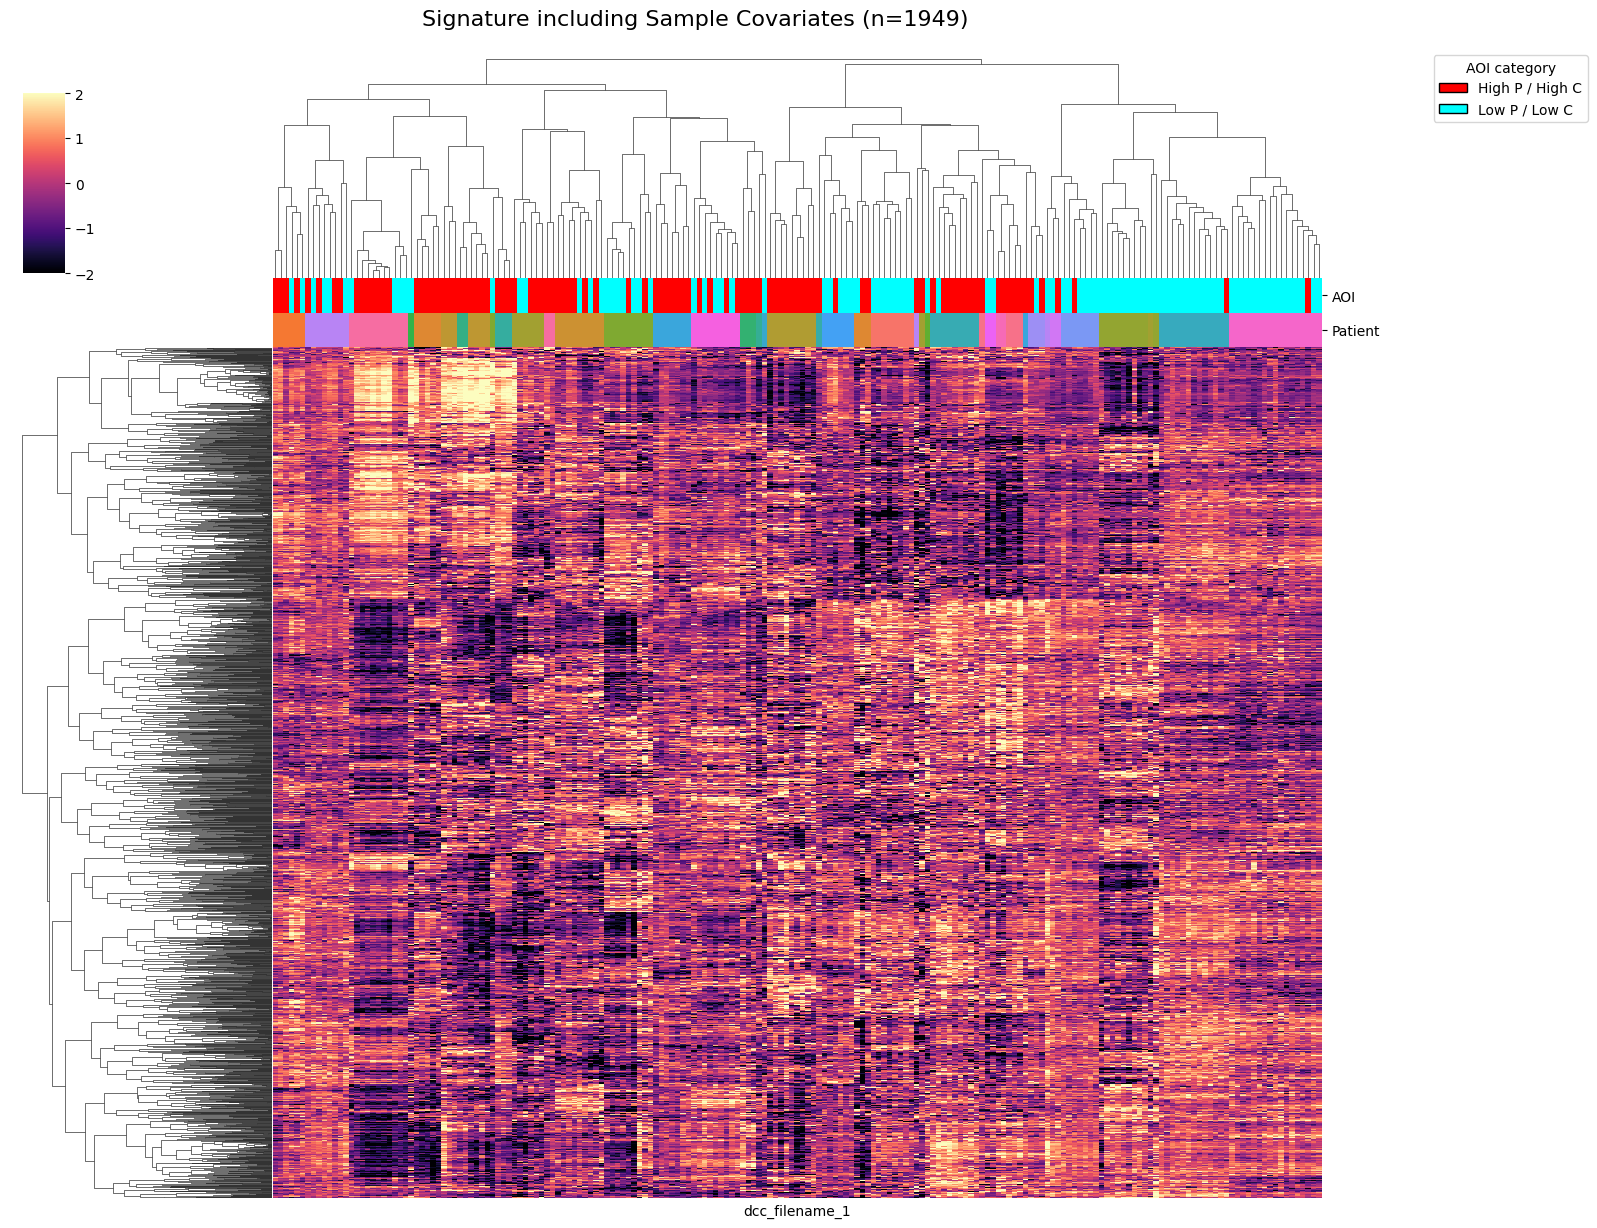

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# 1. Data Preparation & Sample Encoding
# ---------------------------------------------------------
all_pathways = wide_ssgsea.columns.difference(["dcc_filename_1", "Sample"]).tolist()
target_categories = ["High P / High C", "Low P / Low C"]
df_filtered = merged_df_ssgsea[merged_df_ssgsea["AOI_category"].isin(target_categories)].copy()

# One-hot encode Sample (Patient) without a prefix
sample_dummies = pd.get_dummies(df_filtered['Sample'], prefix='', prefix_sep='')
sample_names = sample_dummies.columns.tolist()

# Combine everything into Feature Matrix X
X_full = pd.concat([df_filtered[all_pathways], sample_dummies], axis=1)
X_full = X_full.apply(pd.to_numeric, errors="coerce").fillna(0)
y = df_filtered["AOI_category"]

# ---------------------------------------------------------
# 2. Random Forest Feature Selection
# ---------------------------------------------------------
rf = RandomForestClassifier(n_estimators=2000, random_state=42, class_weight='balanced')
rf.fit(X_full, y)

# Select features above the mean importance
importances = pd.Series(rf.feature_importances_, index=X_full.columns)
threshold = importances.mean()
selected_features = importances[importances >= threshold].sort_values(ascending=False).index

print(f"RF selected {len(selected_features)} features (Pathways + Sample IDs).")

# ---------------------------------------------------------
# 3. Prepare Clustermap Matrix
# ---------------------------------------------------------
# We use the filtered dataframe indexed by ID, but only for selected features
data_to_plot = X_full.loc[df_filtered.index, selected_features].T
data_to_plot.columns = df_filtered["dcc_filename_1"]

# ---------------------------------------------------------
# 4. High-Contrast Annotation Colors
# ---------------------------------------------------------
palette = {
    "High P / High C": "#FF0000", # Vivid Red
    "Low P / Low C": "#00FFFF"    # Cyan
}

sample_col = "Sample_x" if "Sample_x" in df_filtered.columns else "Sample"
unique_samples = df_filtered[sample_col].unique()
sample_pal = dict(zip(unique_samples, sns.color_palette("husl", len(unique_samples))))

col_colors = pd.DataFrame({
    "AOI": df_filtered.set_index("dcc_filename_1")["AOI_category"].map(palette),
    "Patient": df_filtered.set_index("dcc_filename_1")[sample_col].map(sample_pal)
}, index=df_filtered["dcc_filename_1"])

# ---------------------------------------------------------
# 5. HIGH-CONTRAST CLUSTERMAP
# ---------------------------------------------------------
g = sns.clustermap(
    data_to_plot,
    z_score=0,             # Normalize rows
    cmap="magma",          # High contrast: Black to Yellow
    vmin=-2, vmax=2,       # Clip for saturation
    figsize=(14, 12),
    xticklabels=False,
    yticklabels=False,     # Clean right side
    col_colors=col_colors,
    method="complete",
    metric="correlation",
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)

# ---------------------------------------------------------
# 6. Legend & Labels
# ---------------------------------------------------------
handles = [Patch(facecolor=palette[label], edgecolor="black", label=label) for label in target_categories]
g.ax_col_dendrogram.legend(handles=handles, title="AOI category", loc="upper left", bbox_to_anchor=(1.1, 1))

g.fig.suptitle(f"Signature including Sample Covariates (n={len(selected_features)})", y=1.02, fontsize=16)

plt.show()

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. Identify & Filter for REACTOME Pathways ONLY
# ---------------------------------------------------------
# Get all available columns from ssGSEA
full_pathway_list = wide_ssgsea.columns.difference(["dcc_filename_1", "Sample"]).tolist()

# Filter for names starting with REACTOME_
reactome_pathways = [p for p in full_pathway_list if p.upper().startswith('REACTOME_')]

print(f"Total pathways found: {len(full_pathway_list)}")
print(f"Reactome pathways found: {len(reactome_pathways)}")

# ---------------------------------------------------------
# 2. Filter AOI Categories and Prepare X, y
# ---------------------------------------------------------
target_categories = ["High P / High C", "Low P / Low C"]
df_filtered = merged_df_ssgsea[merged_df_ssgsea["AOI_category"].isin(target_categories)].copy()

# Ensure numeric data for Reactome pathways
X = df_filtered[reactome_pathways].apply(pd.to_numeric, errors="coerce").fillna(0)
y = df_filtered["AOI_category"]

# Split data (80/20) for validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------------------------------------
# 3. Train Random Forest
# ---------------------------------------------------------
rf = RandomForestClassifier(n_estimators=2000, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Calculate Importance for ALL data
importances = pd.Series(rf.feature_importances_, index=reactome_pathways).sort_values(ascending=False)

# ---------------------------------------------------------
# 4. DIAGNOSTIC PLOTS (High Contrast)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- A. Top 20 Reactome Feature Importance ---
sns.barplot(x=importances.head(20).values, y=importances.head(20).index, ax=axes[0, 0], palette="magma")
axes[0, 0].set_title("Top 20 Predictive Reactome Pathways", fontsize=14)
axes[0, 0].set_xlabel("Importance Score")

# --- B. Confusion Matrix ---
y_pred = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0, 1], cmap="Purples", colorbar=False)
axes[0, 1].set_title("Model Confusion Matrix (Test Set)", fontsize=14)

# --- C. ROC Curve (Accuracy) ---
y_prob = rf.predict_proba(X_test)[:, 1]
y_test_bin = (y_test == "High P / High C").astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
roc_auc = auc(fpr, tpr)

axes[1, 0].plot(fpr, tpr, color='#FF00FF', lw=3, label=f'AUC = {roc_auc:.2f}') # Neon pink ROC
axes[1, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1, 0].set_title("Prediction Accuracy (ROC)", fontsize=14)
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend(loc="lower right")

# --- D. PCA of Selected Reactome Signature ---
# Use Reactome pathways above median importance
selected_feats = importances[importances >= importances.median()].index
X_selected = X[selected_feats]
pca = PCA(n_components=2)
components = pca.fit_transform(X_selected)

pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['Category'] = y.values

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Category', 
                palette={"High P / High C": "#FF0000", "Low P / Low C": "#00FFFF"}, 
                ax=axes[1, 1], s=120, alpha=0.9, edgecolor="black")
axes[1, 1].set_title(f"PCA using Top Reactome Signature (n={len(selected_feats)})", fontsize=14)

plt.tight_layout()
plt.show()

Total pathways found: 6199
Reactome pathways found: 0


ValueError: at least one array or dtype is required

## Updated colormap for the clustermap

Random Forest selected 3100 pathways.


/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


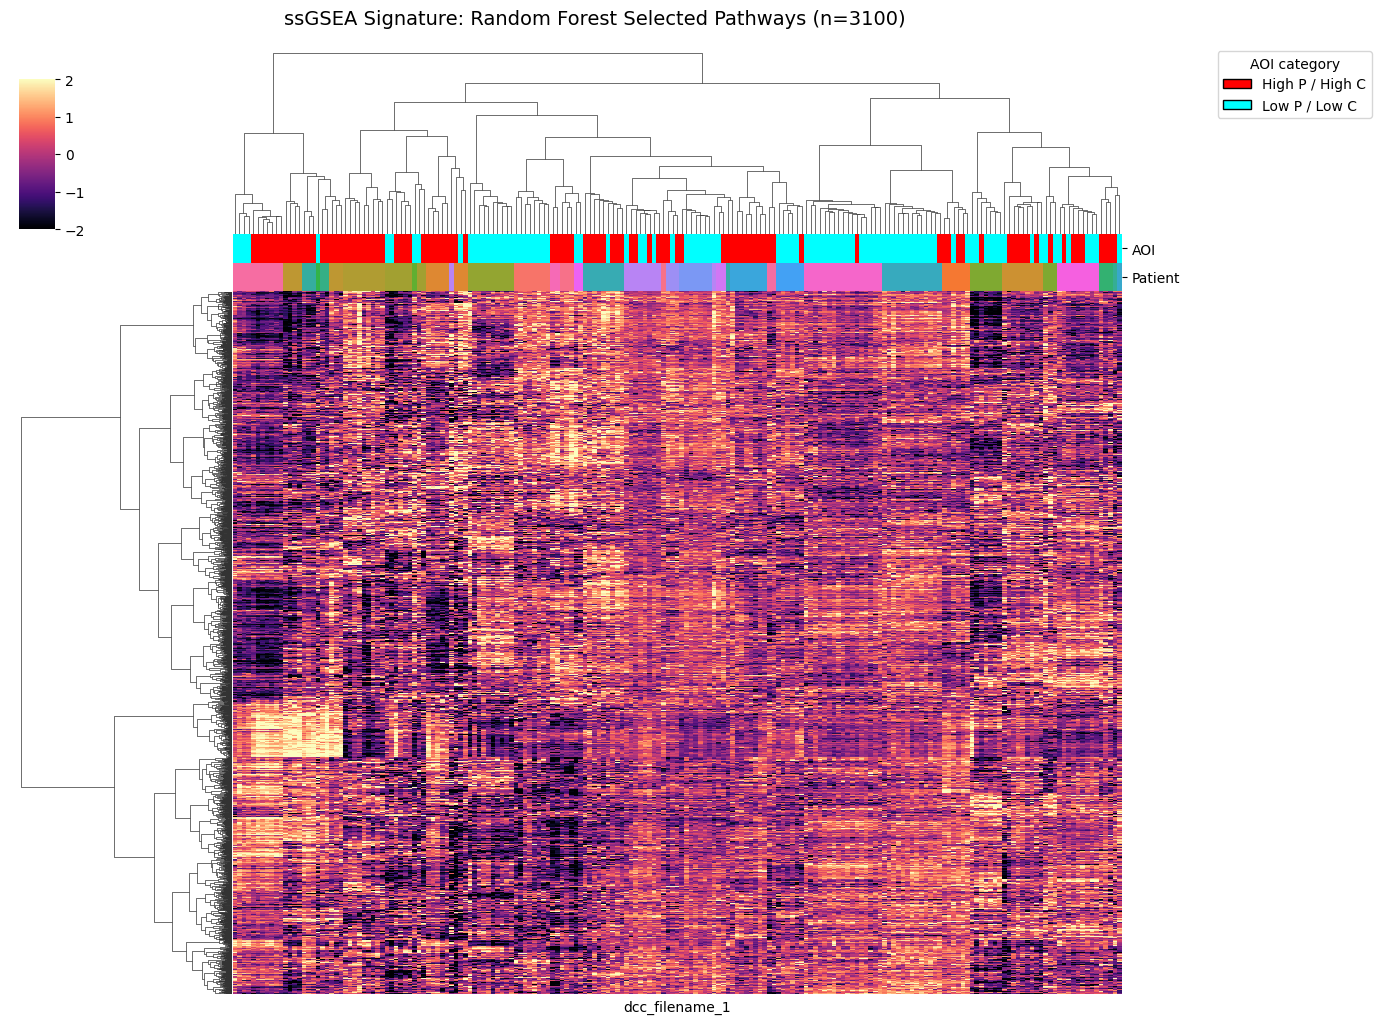

In [33]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1. Identify Pathway Columns & Metadata
# -----------------------------
all_ssgsea_pathways = wide_ssgsea.columns.difference(["dcc_filename_1", "Sample"]).tolist()

# -----------------------------
# 2. Filter for specific categories FIRST
# -----------------------------
target_categories = ["High P / High C", "Low P / Low C"]
df_filtered = merged_df_ssgsea[merged_df_ssgsea["AOI_category"].isin(target_categories)].copy()

# Ensure pathway data is numeric
df_filtered[all_ssgsea_pathways] = df_filtered[all_ssgsea_pathways].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

# -----------------------------
# 3. Random Forest Feature Selection
# -----------------------------
X = df_filtered[all_ssgsea_pathways]
y = df_filtered["AOI_category"]

# Fit Random Forest
rf = RandomForestClassifier(n_estimators=2000, random_state=42, class_weight='balanced')
rf.fit(X, y)

# Extract importance scores
importances = pd.Series(rf.feature_importances_, index=all_ssgsea_pathways)

# Filter: Keep pathways with importance above the median for a broader signature
threshold = importances.median() 
top_pathways_rf = importances[importances >= threshold].sort_values(ascending=False).index

print(f"Random Forest selected {len(top_pathways_rf)} pathways.")

# -----------------------------
# 4. Prepare Matrix
# -----------------------------
data = df_filtered.set_index("dcc_filename_1")[top_pathways_rf].T

# -----------------------------
# 5. High-Contrast Annotation Colors
# -----------------------------
palette = {
    "High P / High C": "#FF0000", # Vivid Red
    "Low P / Low C": "#00FFFF"    # Cyan
}

sample_col = "Sample_x" if "Sample_x" in df_filtered.columns else "Sample"
unique_samples = df_filtered[sample_col].unique()

# Using 'husl' for more saturated patient colors
sample_pal = dict(zip(unique_samples, sns.color_palette("husl", len(unique_samples))))

col_colors = pd.DataFrame({
    "AOI": df_filtered.set_index("dcc_filename_1")["AOI_category"].map(palette),
    "Patient": df_filtered.set_index("dcc_filename_1")[sample_col].map(sample_pal)
})

# -----------------------------
# 6. HIGH-CONTRAST CLUSTERMAP
# -----------------------------
g = sns.clustermap(
    data,
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    z_score=0,             
    cmap="magma",          # High contrast: Black (low) -> Yellow (high)
    vmin=-2,               # Boost contrast by clipping at 2 std devs
    vmax=2,                # Boost contrast by clipping at 2 std devs
    figsize=(12, 10),      
    xticklabels=False,     
    yticklabels=False, 
    method="ward",         # Changed to ward for cleaner block clustering
    metric="euclidean",    # Euclidean works best with Ward linkage
    cbar_pos=(0.02, 0.8, 0.03, 0.15) 
)

# -----------------------------
# 7. Legend
# -----------------------------
handles = [
    Patch(facecolor=palette[label], edgecolor="black", label=label)
    for label in target_categories
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="AOI category",
    loc="upper left",
    bbox_to_anchor=(1.1, 1),
    frameon=True
)

g.fig.suptitle(f"ssGSEA Signature: Random Forest Selected Pathways (n={len(top_pathways_rf)})", y=1.02, fontsize=14)

plt.show()

## Clustering by most variable pathways

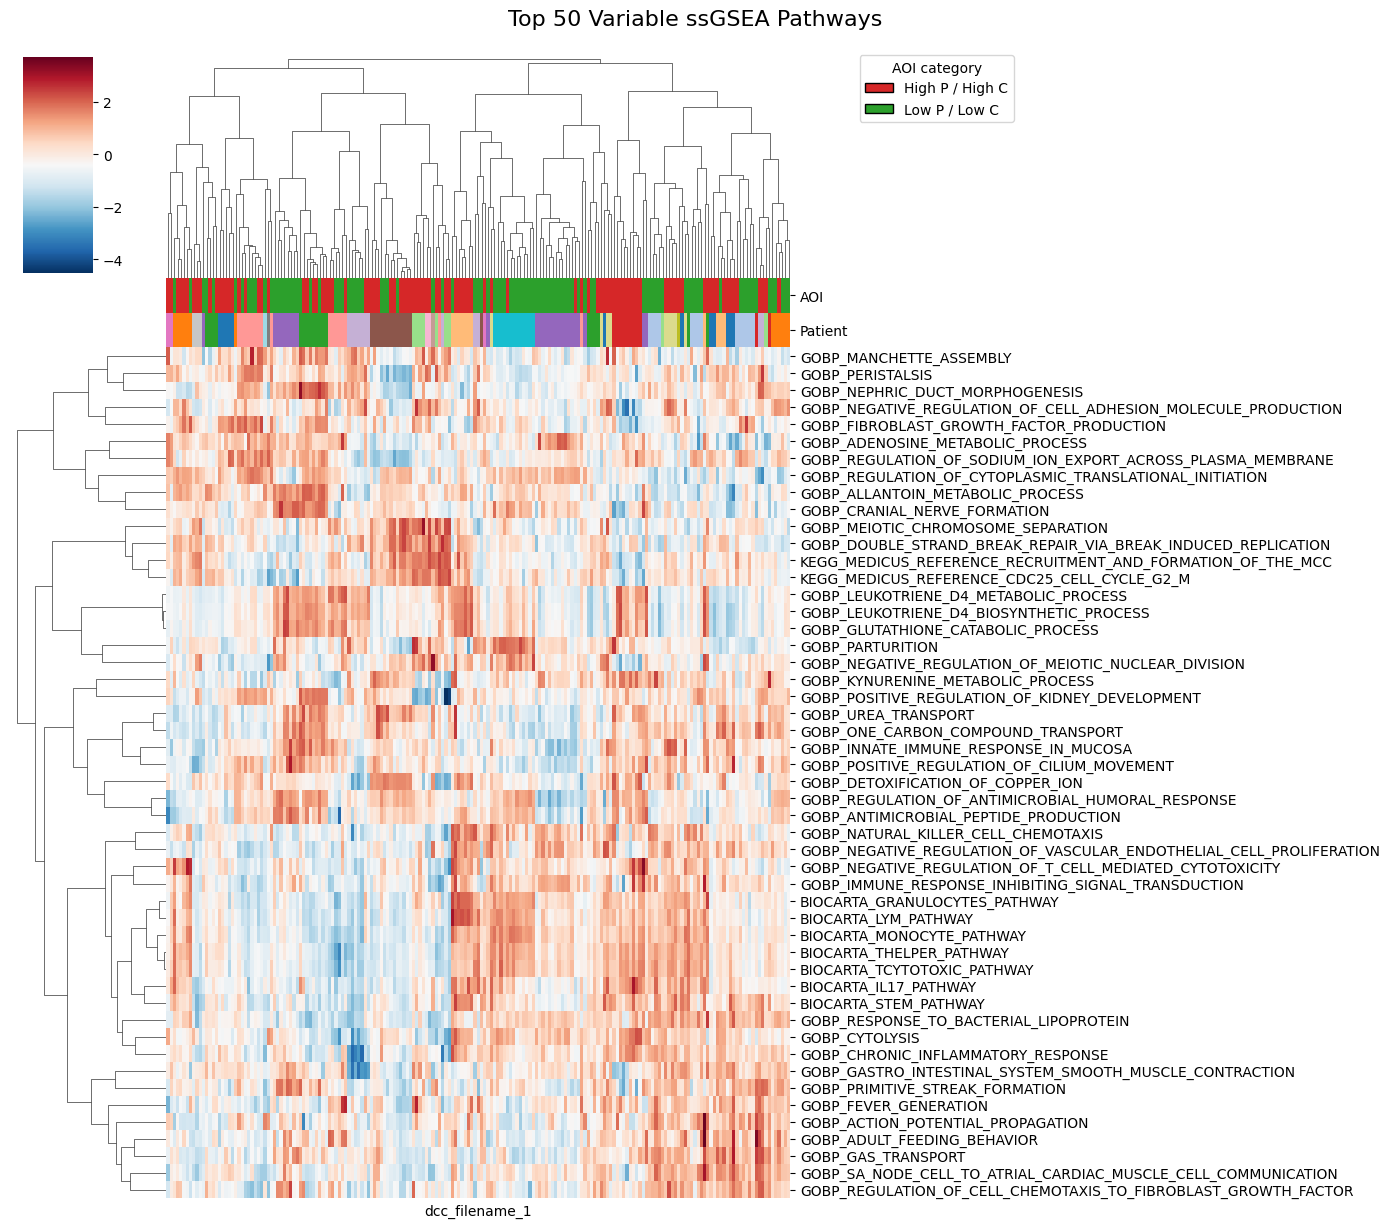

In [25]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# 1. Identify Pathway Columns
# -----------------------------
# Since you merged ssgsea scores with aoi_summary, your pathways are the 
# columns from the original wide_ssgsea (excluding metadata)
all_ssgsea_pathways = wide_ssgsea.columns.difference(["dcc_filename_1", "Sample"]).tolist()

# -----------------------------
# 2. Filter for specific categories FIRST
# -----------------------------
target_categories = ["High P / High C", "Low P / Low C"]
df_filtered = merged_df_ssgsea[merged_df_ssgsea["AOI_category"].isin(target_categories)].copy()

# -----------------------------
# 3. Re-calculate top variable pathways 
# -----------------------------
# Ensure pathway data is numeric
df_filtered[all_ssgsea_pathways] = df_filtered[all_ssgsea_pathways].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

# Calculate variance across the selected categories to find discriminating pathways
var_filtered = df_filtered[all_ssgsea_pathways].var(axis=0)
top_pathways = var_filtered.sort_values(ascending=False).head(50).index

# -----------------------------
# 4. Prepare Matrix
# -----------------------------
data = df_filtered.set_index("dcc_filename_1")[top_pathways].T

# -----------------------------
# 5. Annotation Colors
# -----------------------------
palette = {
    "High P / High C": "#d62728",
    "Low P / Low C": "#2ca02c"
}

unique_samples = df_filtered["Sample_x"].unique() if "Sample_x" in df_filtered.columns else df_filtered["Sample"].unique()
sample_col = "Sample_x" if "Sample_x" in df_filtered.columns else "Sample"

sample_pal = dict(zip(unique_samples, sns.color_palette("tab20", len(unique_samples))))

col_colors = pd.DataFrame({
    "AOI": df_filtered.set_index("dcc_filename_1")["AOI_category"].map(palette),
    "Patient": df_filtered.set_index("dcc_filename_1")[sample_col].map(sample_pal)
})

# -----------------------------
# 6. CLUSTERMAP
# -----------------------------
g = sns.clustermap(
    data,
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    z_score=0,             # Important: Centers the pathway scores
    cmap="RdBu_r",
    figsize=(14, 12),      # Slightly taller to accommodate pathway names
    xticklabels=False,
    yticklabels=True,
    method="complete",
    metric="correlation"
)

# -----------------------------
# 7. Legend
# -----------------------------
handles = [
    Patch(facecolor=palette[label], edgecolor="black", label=label)
    for label in target_categories
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="AOI category",
    loc="upper left",
    bbox_to_anchor=(1.1, 1),
    frameon=True
)

g.fig.suptitle("Top 50 Variable ssGSEA Pathways", y=1.02, fontsize=16)

plt.show()

## Checking clustering with hallmarks

In [5]:
hallmark_ssgsea = ssgsea_scores[
    ssgsea_scores["pathway"].str.startswith("HALLMARK")
]

wide_hallmark_ssgsea = hallmark_ssgsea.pivot(
    index=["dcc_filename", "Sample"],
    columns="pathway",
    values="ssgsea_score"
)
hallmarks_list=wide_hallmark_ssgsea.columns.to_list()
# Rename the index level for clarity
wide_hallmark_ssgsea.index = wide_hallmark_ssgsea.index.rename(["dcc_filename_1", "Sample"])
wide_hallmark_ssgsea =wide_hallmark_ssgsea.reset_index()
wide_hallmark_ssgsea["dcc_filename_1"] = wide_hallmark_ssgsea["dcc_filename_1"].astype(str)
#wide_hallmark_ssgsea["Sample"] = wide_hallmark_ssgsea["Sample"].astype(str)
merged_df = pd.merge(
    wide_hallmark_ssgsea,
    aoi_summary,
    on="dcc_filename_1",
    how="inner"
)


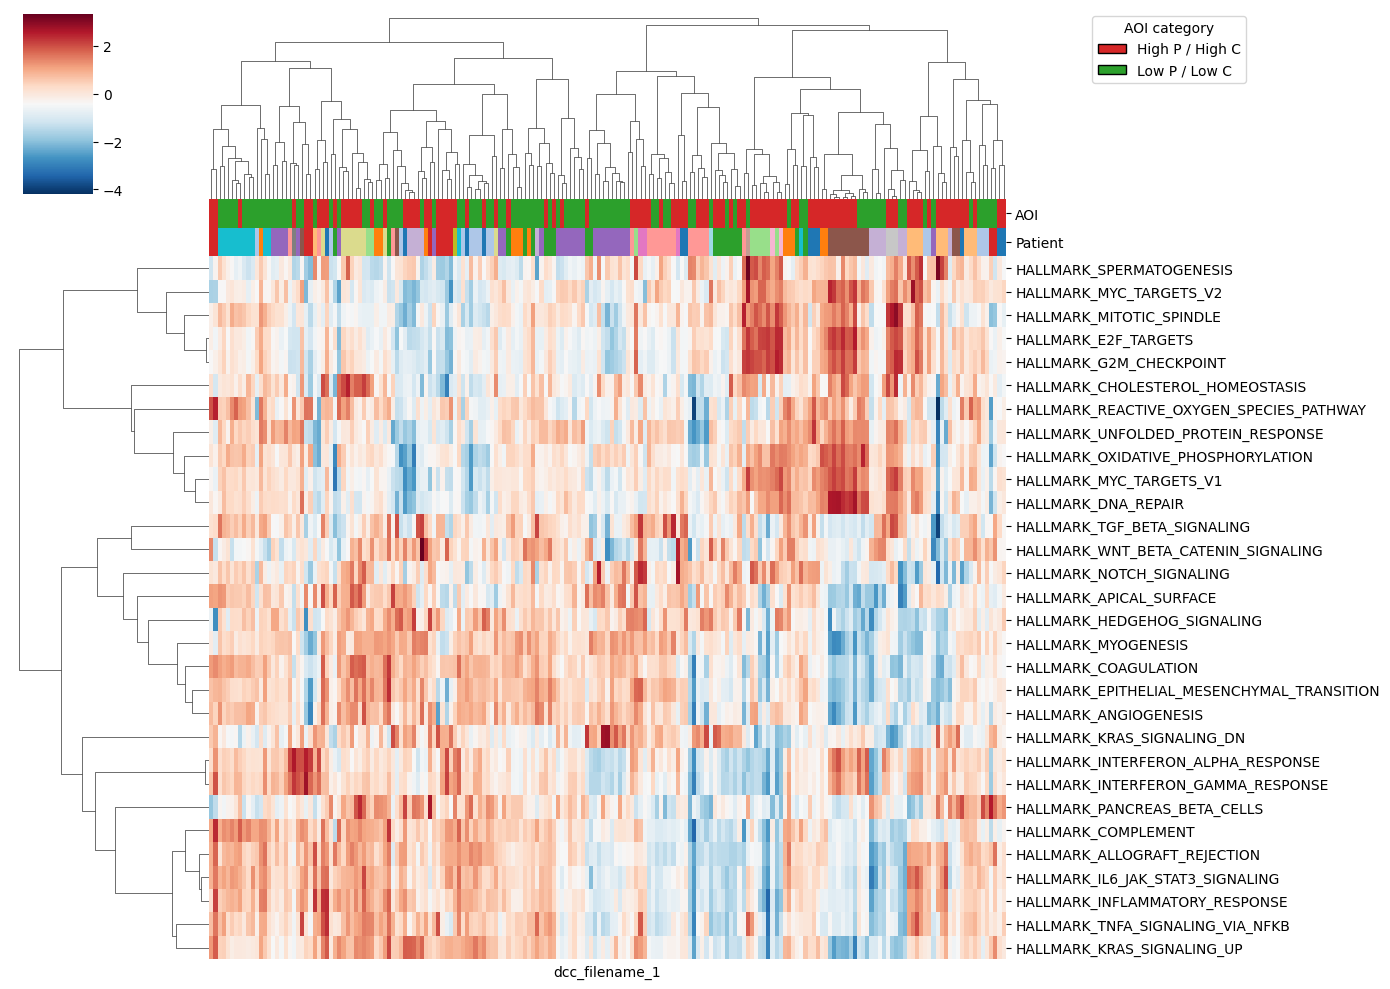

In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# 1. Filter for specific categories FIRST
# -----------------------------
target_categories = ["High P / High C", "Low P / Low C"]
df_filtered = merged_df[merged_df["AOI_category"].isin(target_categories)].copy()

# -----------------------------
# 2. Re-calculate top variable pathways 
# (This ensures the pathways selected distinguish your 2 target groups)
# -----------------------------
df_filtered[hallmarks_list] = df_filtered[hallmarks_list].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

# Calculate variance only on the filtered subset
var_filtered = df_filtered[hallmarks_list].var(axis=0)
top_hallmarks_filtered = var_filtered.sort_values(ascending=False).head(30).index

# -----------------------------
# 3. Prepare Matrix
# -----------------------------
data = df_filtered.set_index("dcc_filename_1")[top_hallmarks_filtered].T

# -----------------------------
# 4. Annotation Colors (Only for subset)
# -----------------------------
# Keep the same palette, but we only plot two
palette = {
    "High P / High C": "#d62728",
    "Low P / Low C": "#2ca02c"
}

# Add Sample/Patient colors if you want to see if Harmony worked!
# This helps you verify if samples still cluster by patient.
unique_samples = df_filtered["Sample"].unique()
sample_pal = dict(zip(unique_samples, sns.color_palette("tab20", len(unique_samples))))

col_colors = pd.DataFrame({
    "AOI": df_filtered.set_index("dcc_filename_1")["AOI_category"].map(palette),
    "Patient": df_filtered.set_index("dcc_filename_1")["Sample"].map(sample_pal)
})

# -----------------------------
# 5. CLUSTERMAP
# -----------------------------
g = sns.clustermap(
    data,
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    z_score=0,             # Centers colors: Red=High, Blue=Low relative to mean
    cmap="RdBu_r",
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=True,
    method="complete",     # 'complete' often produces cleaner clusters for GSVA/ssGSEA
    metric="correlation"
)

# -----------------------------
# 6. Legend (Target groups only)
# -----------------------------
handles = [
    Patch(facecolor=palette[label], edgecolor="black", label=label)
    for label in target_categories
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="AOI category",
    loc="upper left",
    bbox_to_anchor=(1.1, 1),
    frameon=True
)

plt.show()

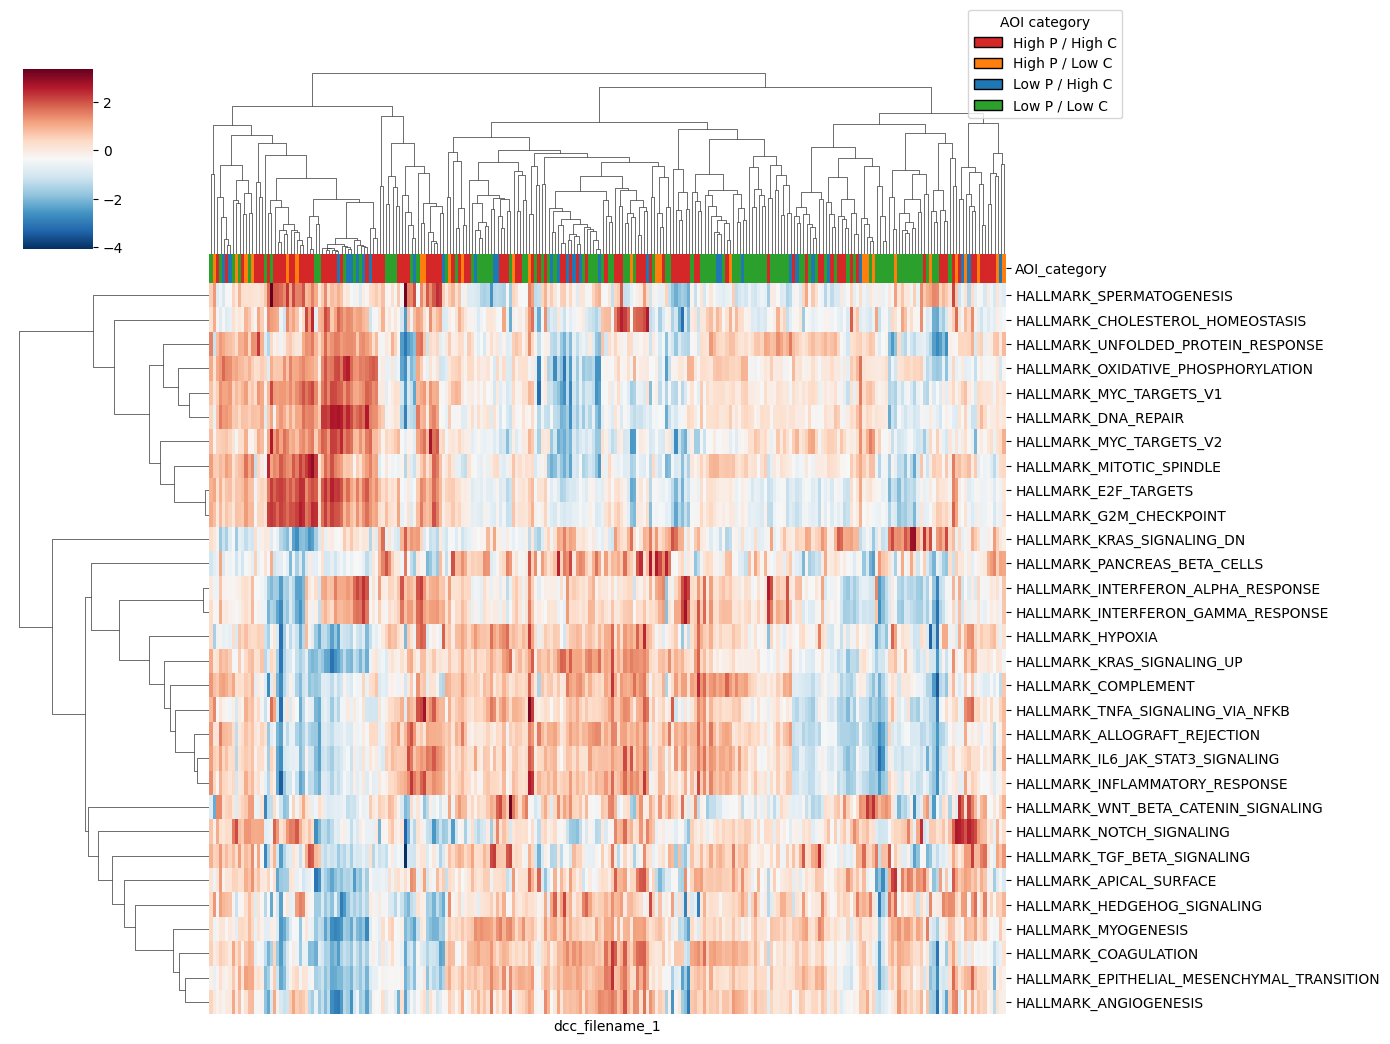

In [15]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# 1. Clean AOI category
# -----------------------------
merged_df["AOI_category"] = merged_df["AOI_category"].astype(str)

# -----------------------------
# 2. Ensure numeric hallmarks
# -----------------------------
merged_df[hallmarks_list] = merged_df[hallmarks_list].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

# -----------------------------
# 3. Select most variable pathways
# -----------------------------
var = merged_df[hallmarks_list].var(axis=0)
top_hallmarks = var.sort_values(ascending=False).head(30).index

# -----------------------------
# 4. MATRIX
# rows = pathways (Y-axis)
# columns = AOIs (X-axis)
# -----------------------------
data = merged_df.set_index("dcc_filename_1")[top_hallmarks].T

# -----------------------------
# 5. AOI annotation (columns)
# -----------------------------
palette = {
    "High P / High C": "#d62728",
    "High P / Low C": "#ff7f0e",
    "Low P / High C": "#1f77b4",
    "Low P / Low C": "#2ca02c"
}

col_colors = merged_df.set_index("dcc_filename_1")["AOI_category"].map(palette)
col_colors = col_colors.loc[data.columns]

# -----------------------------
# 6. CLUSTERMAP
# BOTH axes clustered (no flipping)
# -----------------------------
g = sns.clustermap(
    data,
    col_colors=col_colors,
    row_cluster=True,      # 🔥 cluster pathways (Y-axis)
    col_cluster=True,      # 🔥 cluster AOIs (X-axis)
    z_score=0,
    cmap="RdBu_r",
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=True,
    method="average",
    metric="correlation"
)

# -----------------------------
# 7. Legend
# -----------------------------
handles = [
    Patch(facecolor=color, edgecolor="black", label=label)
    for label, color in palette.items()
]

g.ax_col_dendrogram.legend(
    handles=handles,
    title="AOI category",
    loc="center",
    bbox_to_anchor=(1.05, 1),
    frameon=True
)

plt.show()